In [ ]:
# Install required libraries
!pip install -q kaggle tensorflow matplotlib seaborn scikit-learn

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'NID']


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/NID/nid-3775805504.pdf


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'NID', 'archive.zip']


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['chest_xray']


In [ ]:
import os

dataset_path = '/content/dataset/chest_xray'

for item in os.listdir(dataset_path):
    print(item)

__MACOSX
chest_xray
val
test
train


In [ ]:
import os

base_path = '/content/dataset/chest_xray'

print(os.listdir(base_path))

['__MACOSX', 'chest_xray', 'val', 'test', 'train']


In [ ]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    if 'Train' in dirs:
        print("TRAIN PATH:", os.path.join(root, 'Train'))
    if 'Test' in dirs:
        print("TEST PATH:", os.path.join(root, 'Test'))
    if 'Val' in dirs:
        print("VAL PATH:", os.path.join(root, 'Val'))

In [ ]:
import os

print("Dataset folders:")

for root, dirs, files in os.walk('/content/dataset'):
    print(root)

Dataset folders:
/content/dataset
/content/dataset/chest_xray
/content/dataset/chest_xray/__MACOSX
/content/dataset/chest_xray/__MACOSX/chest_xray
/content/dataset/chest_xray/__MACOSX/chest_xray/val
/content/dataset/chest_xray/__MACOSX/chest_xray/val/NORMAL
/content/dataset/chest_xray/__MACOSX/chest_xray/val/PNEUMONIA
/content/dataset/chest_xray/__MACOSX/chest_xray/test
/content/dataset/chest_xray/__MACOSX/chest_xray/test/NORMAL
/content/dataset/chest_xray/__MACOSX/chest_xray/test/PNEUMONIA
/content/dataset/chest_xray/__MACOSX/chest_xray/train
/content/dataset/chest_xray/__MACOSX/chest_xray/train/NORMAL
/content/dataset/chest_xray/__MACOSX/chest_xray/train/PNEUMONIA
/content/dataset/chest_xray/chest_xray
/content/dataset/chest_xray/chest_xray/val
/content/dataset/chest_xray/chest_xray/val/NORMAL
/content/dataset/chest_xray/chest_xray/val/PNEUMONIA
/content/dataset/chest_xray/chest_xray/test
/content/dataset/chest_xray/chest_xray/test/NORMAL
/content/dataset/chest_xray/chest_xray/test/P

In [ ]:
import os

base_path = '/content/dataset/chest_xray/chest_xray'

for folder in ['train', 'test', 'val']:
    print('\n' + folder.upper())

    for class_name in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(base_path, folder, class_name)
        print(class_name, ':', len(os.listdir(path)))


TRAIN
NORMAL : 1342
PNEUMONIA : 3876

TEST
NORMAL : 234
PNEUMONIA : 390

VAL
NORMAL : 9
PNEUMONIA : 9


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Dataset paths
base_path = '/content/dataset/chest_xray/chest_xray'

train_path = base_path + '/train'
test_path = base_path + '/test'
val_path = base_path + '/val'

# Image settings
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Data loading completed!")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Data loading completed!


In [ ]:
from tensorflow.keras import layers, models

# CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the CNN model

EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.8451 - loss: 0.3577 - val_accuracy: 0.8125 - val_loss: 0.5247
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.9141 - loss: 0.2199 - val_accuracy: 0.7500 - val_loss: 0.6377
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.9327 - loss: 0.1826 - val_accuracy: 0.7500 - val_loss: 0.5018
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.9404 - loss: 0.1607 - val_accuracy: 0.9375 - val_loss: 0.4048
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9360 - loss: 0.1624 - val_accuracy: 0.9375 - val_loss: 0.2624
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.9408 - loss: 0.1590 - val_accuracy: 0.5625 - val_loss: 0.6046
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.9459 - loss: 0.1388 - val_accuracy: 0.6875 - val_loss: 0.7344
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.9523 - loss: 0.1257 - val_accu

In [ ]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 625ms/step - accuracy: 0.7821 - loss: 0.7465
Test Loss: 0.7464574575424194
Test Accuracy: 0.7820512652397156
Test Accuracy (%): 78.20512652397156


In [ ]:
import numpy as np

predictions = model.predict(test_data)

predicted_classes = (predictions > 0.5).astype(int).flatten()
actual_classes = test_data.classes

class_names = list(test_data.class_indices.keys())

print("Class mapping:", test_data.class_indices)
print("\nFirst 10 Predictions:\n")

for i in range(10):
    predicted = class_names[predicted_classes[i]]
    actual = class_names[actual_classes[i]]

    print(f"{i+1}. Predicted: {predicted} | Actual: {actual}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 602ms/step
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}

First 10 Predictions:

1. Predicted: NORMAL | Actual: NORMAL
2. Predicted: PNEUMONIA | Actual: NORMAL
3. Predicted: PNEUMONIA | Actual: NORMAL
4. Predicted: PNEUMONIA | Actual: NORMAL
5. Predicted: NORMAL | Actual: NORMAL
6. Predicted: PNEUMONIA | Actual: NORMAL
7. Predicted: NORMAL | Actual: NORMAL
8. Predicted: PNEUMONIA | Actual: NORMAL
9. Predicted: NORMAL | Actual: NORMAL
10. Predicted: PNEUMONIA | Actual: NORMAL


In [ ]:
# Save the trained CNN model

model.save('/content/drive/MyDrive/chest_xray_cnn_model.keras')

print("Model saved successfully!")

Model saved successfully!


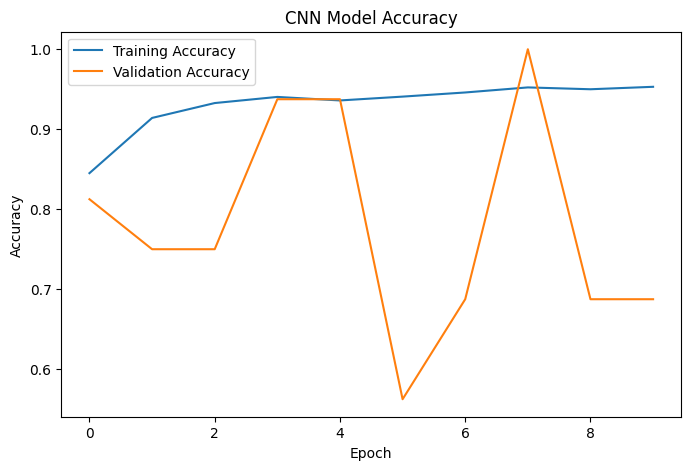

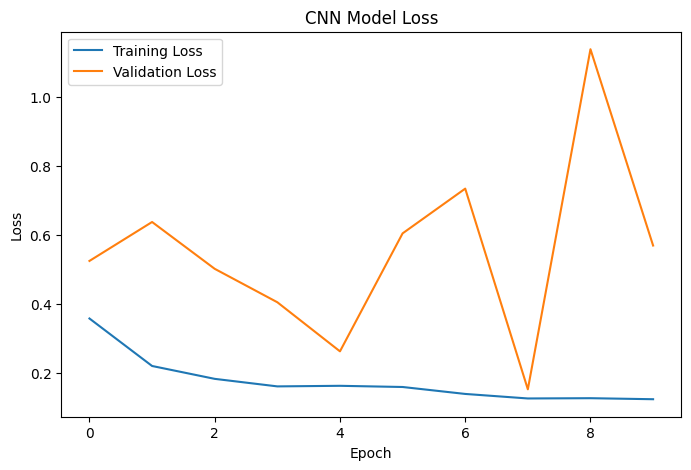

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print("===== FINAL PROJECT RESULT =====")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print("Model: CNN")
print("Classes: NORMAL, PNEUMONIA")
print("Training Images: 5216")
print("Testing Images: 624")
print("Validation Images: 16")

===== FINAL PROJECT RESULT =====
Test Accuracy: 78.21%
Test Loss: 0.7465
Model: CNN
Classes: NORMAL, PNEUMONIA
Training Images: 5216
Testing Images: 624
Validation Images: 16


In [ ]:
print("Test Accuracy:", test_accuracy * 100, "%")

Test Accuracy: 78.20512652397156 %
